In [62]:
# Tiến hành import thư viện để xử lí
import pandas as pd
import numpy as np
import json
from sqlalchemy import create_engine
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [63]:
engine = create_engine("sqlite:///../data/sample_strategy/sample_v4.db")

In [64]:
tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'country', 'time']

In [65]:
df = pd.read_sql('select * from NearsestSample where TimeDim >= 2000 AND SpatialDim = "VNM" order by TimeDim', engine)
df.drop(columns=['id', 'x7'], inplace=True)

In [66]:
df.columns = tables

In [67]:
df.head(n=50)

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
0,124.200000,NaN,49.256360,19.900000,4.2,4.100000,3.1,16.021688,57.2,VNM,2000
1,119.100000,NaN,38.567233,20.000000,3.1,4.800000,4.2,14.037308,6.6,VNM,2000
2,26.600000,NaN,56.564396,19.900000,1.1,4.500000,3.7,17.590483,31.9,VNM,2000
3,31.100000,NaN,45.876804,0.410509,4.3,4.927130,3.2,14.776982,31.9,VNM,2000
4,22.800000,NaN,35.451625,0.305680,3.0,5.128270,3.1,14.037308,31.9,VNM,2000
5,26.400000,NaN,55.475074,29.315099,1.1,29.698873,4.2,18.600342,31.9,VNM,2000
6,30.100000,NaN,38.567233,28.509066,4.3,26.075304,4.1,17.590483,31.9,VNM,2000
7,22.900000,NaN,38.665636,30.096379,3.0,28.278705,4.1,16.901789,31.9,VNM,2000
8,29.688459,NaN,57.347136,0.182635,1.1,4.700000,4.3,18.081457,31.9,VNM,2000
9,22.291992,NaN,56.564396,5.070365,3.1,4.800000,4.3,18.081457,31.9,VNM,2000


In [68]:
# Thử in mô tả dữ liệu
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
count,215.000000,124.000000,215.000000,215.000000,215.000000,215.000000,188.000000,215.000000,215.000000,215.000000
mean,57.829404,7484.192657,53.620868,13.219386,2.796744,18.556085,4.375532,20.979627,28.073023,2009.125581
std,119.652139,68708.189361,58.156850,9.586724,1.373664,31.043880,0.489829,4.048802,17.591853,5.659171
min,22.291992,24.526000,0.200000,0.182635,1.000000,4.100000,3.100000,14.037308,1.500000,2000.000000
25%,26.380237,115.152500,39.386116,1.356476,1.100000,4.960360,4.100000,18.081457,4.600000,2004.000000
50%,30.500000,275.682000,43.707976,15.508048,3.200000,5.100000,4.400000,20.728701,27.800000,2009.000000
75%,40.700000,636.536500,55.869465,21.000000,4.300000,30.163123,4.800000,23.100967,46.200000,2014.000000
max,1220.000000,763443.248700,556.000000,30.096379,4.700000,275.000000,5.000000,33.572872,57.200000,2019.000000


In [69]:
# Thử tiến hành bỏ qua các giá trị NULL
df.dropna(inplace=True)

In [70]:
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
count,97.000000,97.00000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,46.814430,8335.70909,49.481709,13.266562,2.830928,13.627268,4.680412,22.355538,33.711340,2011.917526
std,34.873600,77469.74413,27.497519,8.866426,1.394660,12.352258,0.292845,2.866783,16.147613,2.556324
min,22.535559,24.52600,21.151084,0.465410,1.000000,4.681230,3.800000,16.568914,2.200000,2008.000000
25%,26.763306,116.55600,41.564109,1.186075,1.100000,5.000000,4.600000,20.197729,24.200000,2010.000000
50%,32.300000,301.02500,42.246865,17.669815,3.300000,5.100000,4.800000,22.124281,26.500000,2012.000000
75%,42.300000,666.20800,55.869465,21.200000,4.300000,28.399640,4.900000,23.864973,49.700000,2014.000000
max,127.300000,763443.24870,285.000000,23.936808,4.600000,34.061864,5.000000,29.853064,51.600000,2016.000000


In [71]:
# Thử in lại một số điểm đầu của dữ liệu
df.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
91,125.9,1750.390,285.000000,20.800000,4.3,5.00000,3.9,17.569860,27.8,VNM,2008
92,120.1,55.916,102.000000,20.800000,3.2,5.10000,4.7,20.197729,4.0,VNM,2008
93,34.2,183.405,41.476797,20.700000,1.1,5.00000,4.3,22.365805,51.6,VNM,2008
94,39.3,93.053,54.385679,0.581034,4.4,4.96371,4.0,20.197729,3.2,VNM,2008
95,29.9,206.299,27.353146,0.465410,3.2,4.89322,3.8,22.365805,26.5,VNM,2008


In [72]:
def draw_histogram(column):
    var = df[column]
    plt.figure(figsize=(6, 4))
    sns.histplot(var, kde=True)
    plt.title(f"Phân phối dữ liệu của {column}")
    plt.ylabel("Số lượng")
    plt.xlabel("Biên độ giá trị")
    plt.show()

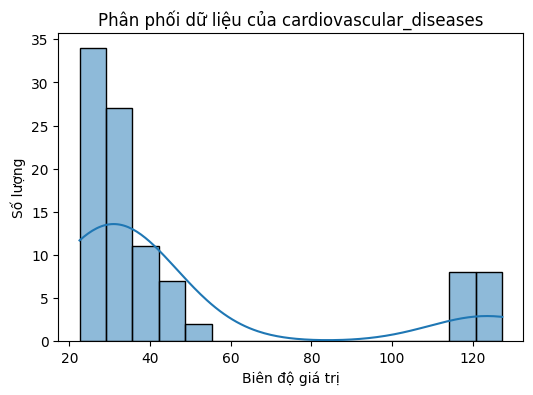

In [73]:
draw_histogram('cardiovascular_diseases')

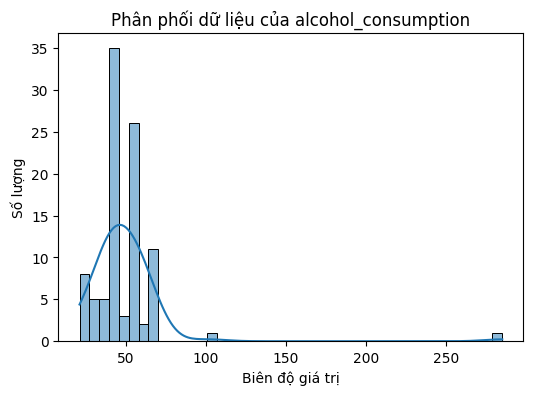

In [74]:
draw_histogram('alcohol_consumption')

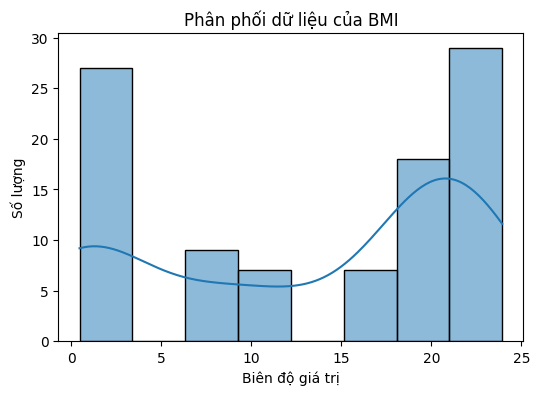

In [75]:
draw_histogram('BMI')

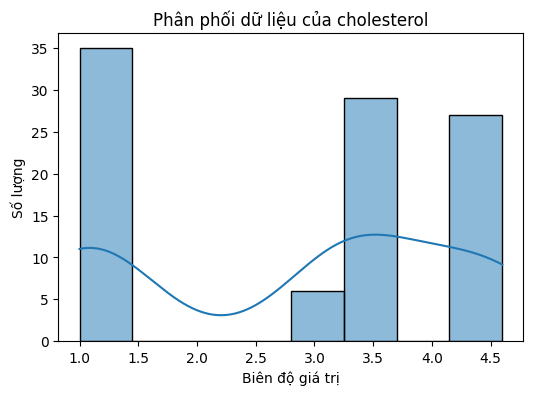

In [76]:
draw_histogram('cholesterol')

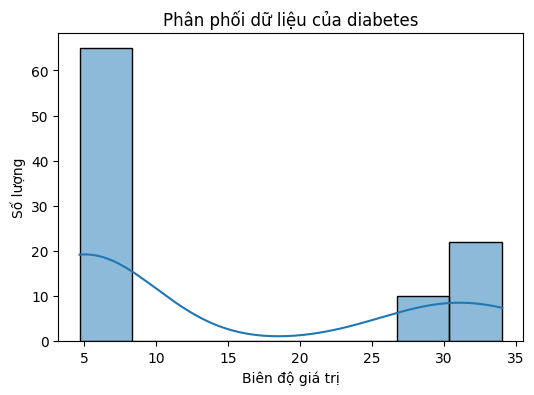

In [77]:
draw_histogram('diabetes')

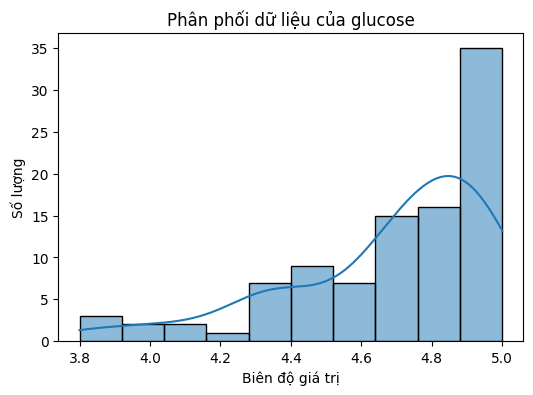

In [78]:
draw_histogram('glucose')

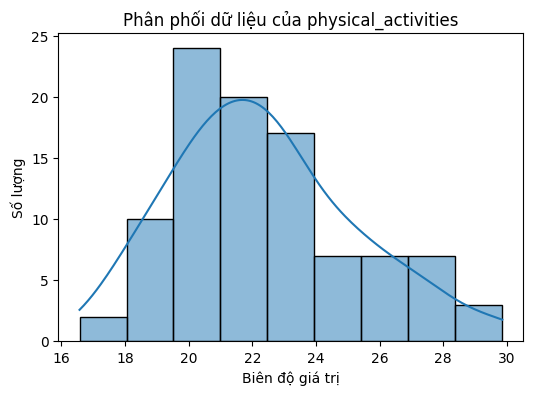

In [79]:
draw_histogram('physical_activities')

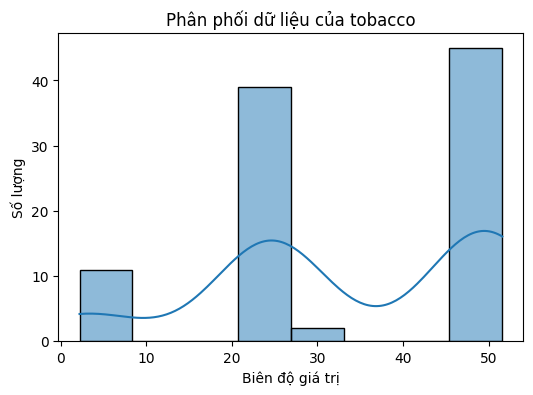

In [80]:
draw_histogram('tobacco')

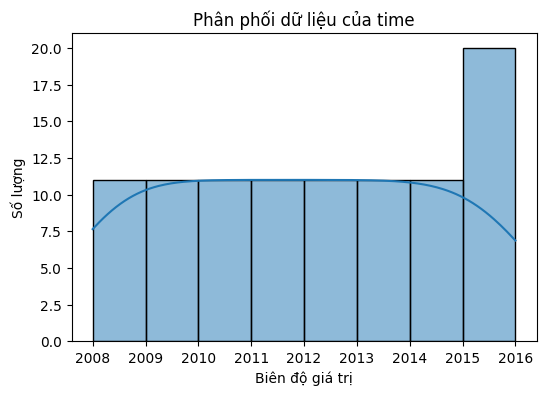

In [81]:
draw_histogram('time')

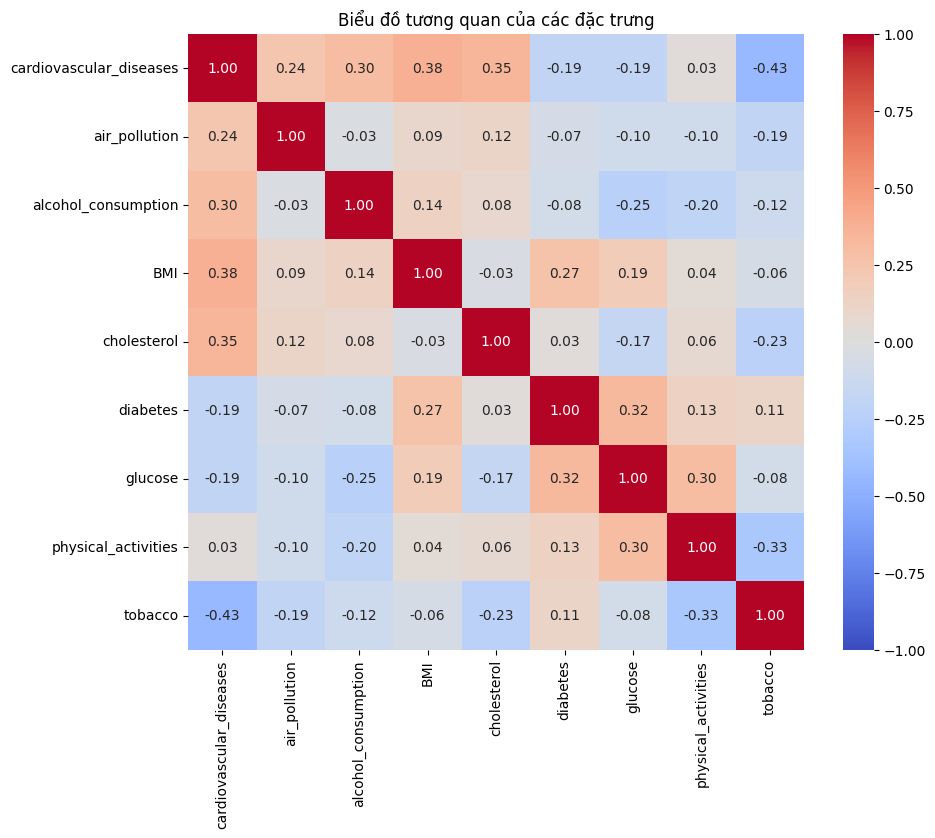

In [82]:
# Thử vẽ ma trận tương quan dữ liệu
# Diabetes là cột dữ liệu về kiểm soát nồng độ nên nó có tương quan âm với các thành phần còn lại
vars = tables.copy()
vars.pop()
vars.pop()

corr = df[vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # hiện giá trị corr
    fmt=".2f",
    cmap="coolwarm",   # thang màu phổ biến cho corr
    vmin=-1, vmax=1,
    square=True
)
plt.title("Biểu đồ tương quan của các đặc trưng")
plt.show()

In [83]:
# Tiến hành chia dữ liệu
df_model = df.copy()
y = df_model['cardiovascular_diseases']
df_model.drop(columns=['cardiovascular_diseases', 'country', 'time'], inplace=True)
X = df_model

In [84]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X, y):
    # Ko cần chia để test
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [85]:
coef, inter = run_for_linear(X, y)

MSE: 585.9338358270537
R2: 0.513194448598731
Coefficients: [ 3.56897356e-05  1.62029070e-01  1.70188310e+00  6.37016887e+00
 -6.15163260e-01 -1.72902448e+01 -4.79877424e-02 -6.63829597e-01]
Intercept: 110.64767734389027


In [86]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

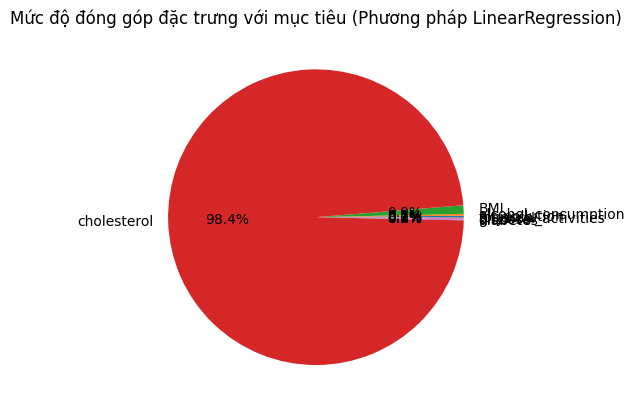

In [87]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu
plt.figure()
plt.pie(softmax(coef), labels=X.columns, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [88]:
def run_for_random_forest(X, y):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [89]:
impor = run_for_random_forest(X, y)

MSE: 35.78956173974445
R2: 0.9702653161981439
Feature Importances: [0.05914276 0.03686645 0.35224492 0.11224131 0.04727925 0.01504495
 0.02392896 0.3532514 ]


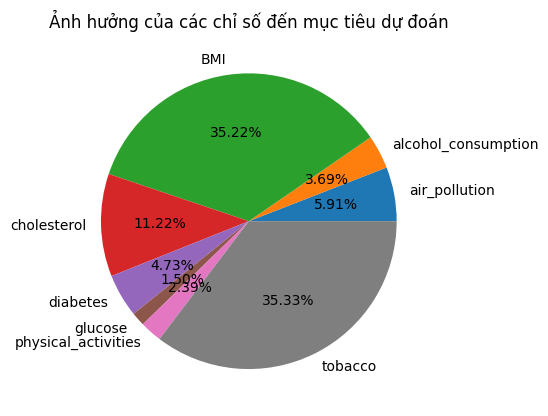

In [93]:
plt.figure()
plt.pie(impor.tolist(), labels=X.columns, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [90]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(X.columns, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

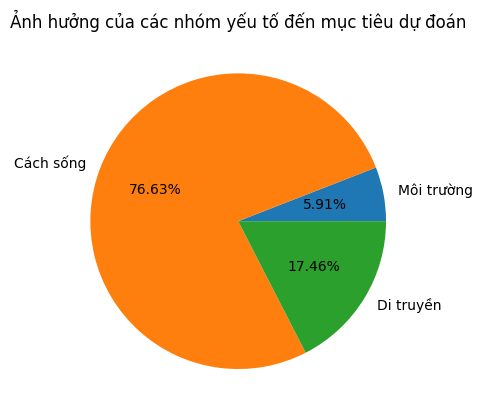

In [91]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")